## Set current dir to project root dir

In [1]:
path <- getwd()
markers <- c(".git", "Makefile", "renv.lock", ".Rprofile")
while (!any(file.exists(file.path(path, markers)))) {
  parent <- dirname(path)
  if (parent == path) stop("Could not find project root")
  path <- parent
}
setwd(path)
rm(path, parent, markers)

## Activate project's local R env. using renv

In [2]:
if (file.exists("renv/activate.R")) {
  source("renv/activate.R")
} else {
  stop("Could not find renv/activate.R in project root")
}

## Imports

In [3]:
options(repr.plot.width = 20, repr.plot.height = 15)
library(eegUtils)


Attaching package: ‘eegUtils’


The following object is masked from ‘package:stats’:

    filter




## Functions

In [4]:
# Standard 10-20 electrode locations
# eegUtils does not support "standard_1020" as a montage string.
# Coordinates below match MNE's standard_1020 montage for the 27 scalp
# channels present in this dataset. Non-EEG channels (HEL, HER, VER, LM, RM)
# are assigned NA and are harmless.
locs <- data.frame(
  electrode = c("Fp1","Fp2","Fz","F3","F4","F7","F8",
                "FC1","FC2","FC5","FC6",
                "Cz","C3","C4","T7","T8",
                "CP1","CP2","CP5","CP6",
                "Pz","P3","P4","P7","P8",
                "O1","O2","Oz"),
  x = c(-0.308, 0.308, 0.000,-0.231, 0.231,-0.587, 0.587,
         -0.197, 0.197,-0.573, 0.573,
          0.000,-0.397, 0.397,-0.719, 0.719,
         -0.197, 0.197,-0.573, 0.573,
          0.000,-0.231, 0.231,-0.587, 0.587,
         -0.308, 0.308, 0.000),
  y = c( 0.756, 0.756, 0.656, 0.594, 0.594, 0.381, 0.381,
          0.370, 0.370, 0.095, 0.095,
          0.000, 0.000, 0.000, 0.000, 0.000,
         -0.370,-0.370,-0.095,-0.095,
         -0.656,-0.594,-0.594,-0.381,-0.381,
         -0.756,-0.756,-0.900),
  stringsAsFactors = FALSE
)

assign_montage <- function(raw) {
  matched       <- locs[match(channel_names(raw), locs$electrode), ]
  channels(raw) <- matched
  raw
}

## Load and inspect

In [5]:
# Path to header file
file_path <- "./ds006018/sub-001/eeg/sub-001_task-flanker_eeg.vhdr"

In [6]:
# Load the raw data
raw <- import_raw(file_path)

Importing Brain Vision Analyzer file ./ds006018/sub-001/eeg/sub-001_task-flanker_eeg.vhdr



In [7]:
# Print basic info (sampling rate, number of channels, etc.)
print(raw)

EEG data

Number of channels	: 31 
Electrode names		: Fp1 Fz F3 F7 HEL FC5 FC1 C3 T7 LM CP5 CP1 Pz P3 P7 O1 Oz O2 P4 P8 RM CP6 CP2 C4 HER VER FC6 FC2 F4 F8 Fp2 
Sampling rate		: 500 Hz
Reference		: 
Signal length: 0 792.658 seconds

In [8]:
# 1. Set the montage (Standard 10-20 system for electrode locations)
raw <- assign_montage(raw)

In [9]:
# 2. Filtering (Standard for EEG: 0.1Hz to 40Hz)
raw <- eeg_filter(raw, low_freq = 0.1, high_freq = 40.0, method = "iir")

Band-pass IIR filter from 0.1 - 40 Hz

Effective filter order: 4 (two-pass)

Removing channel means...



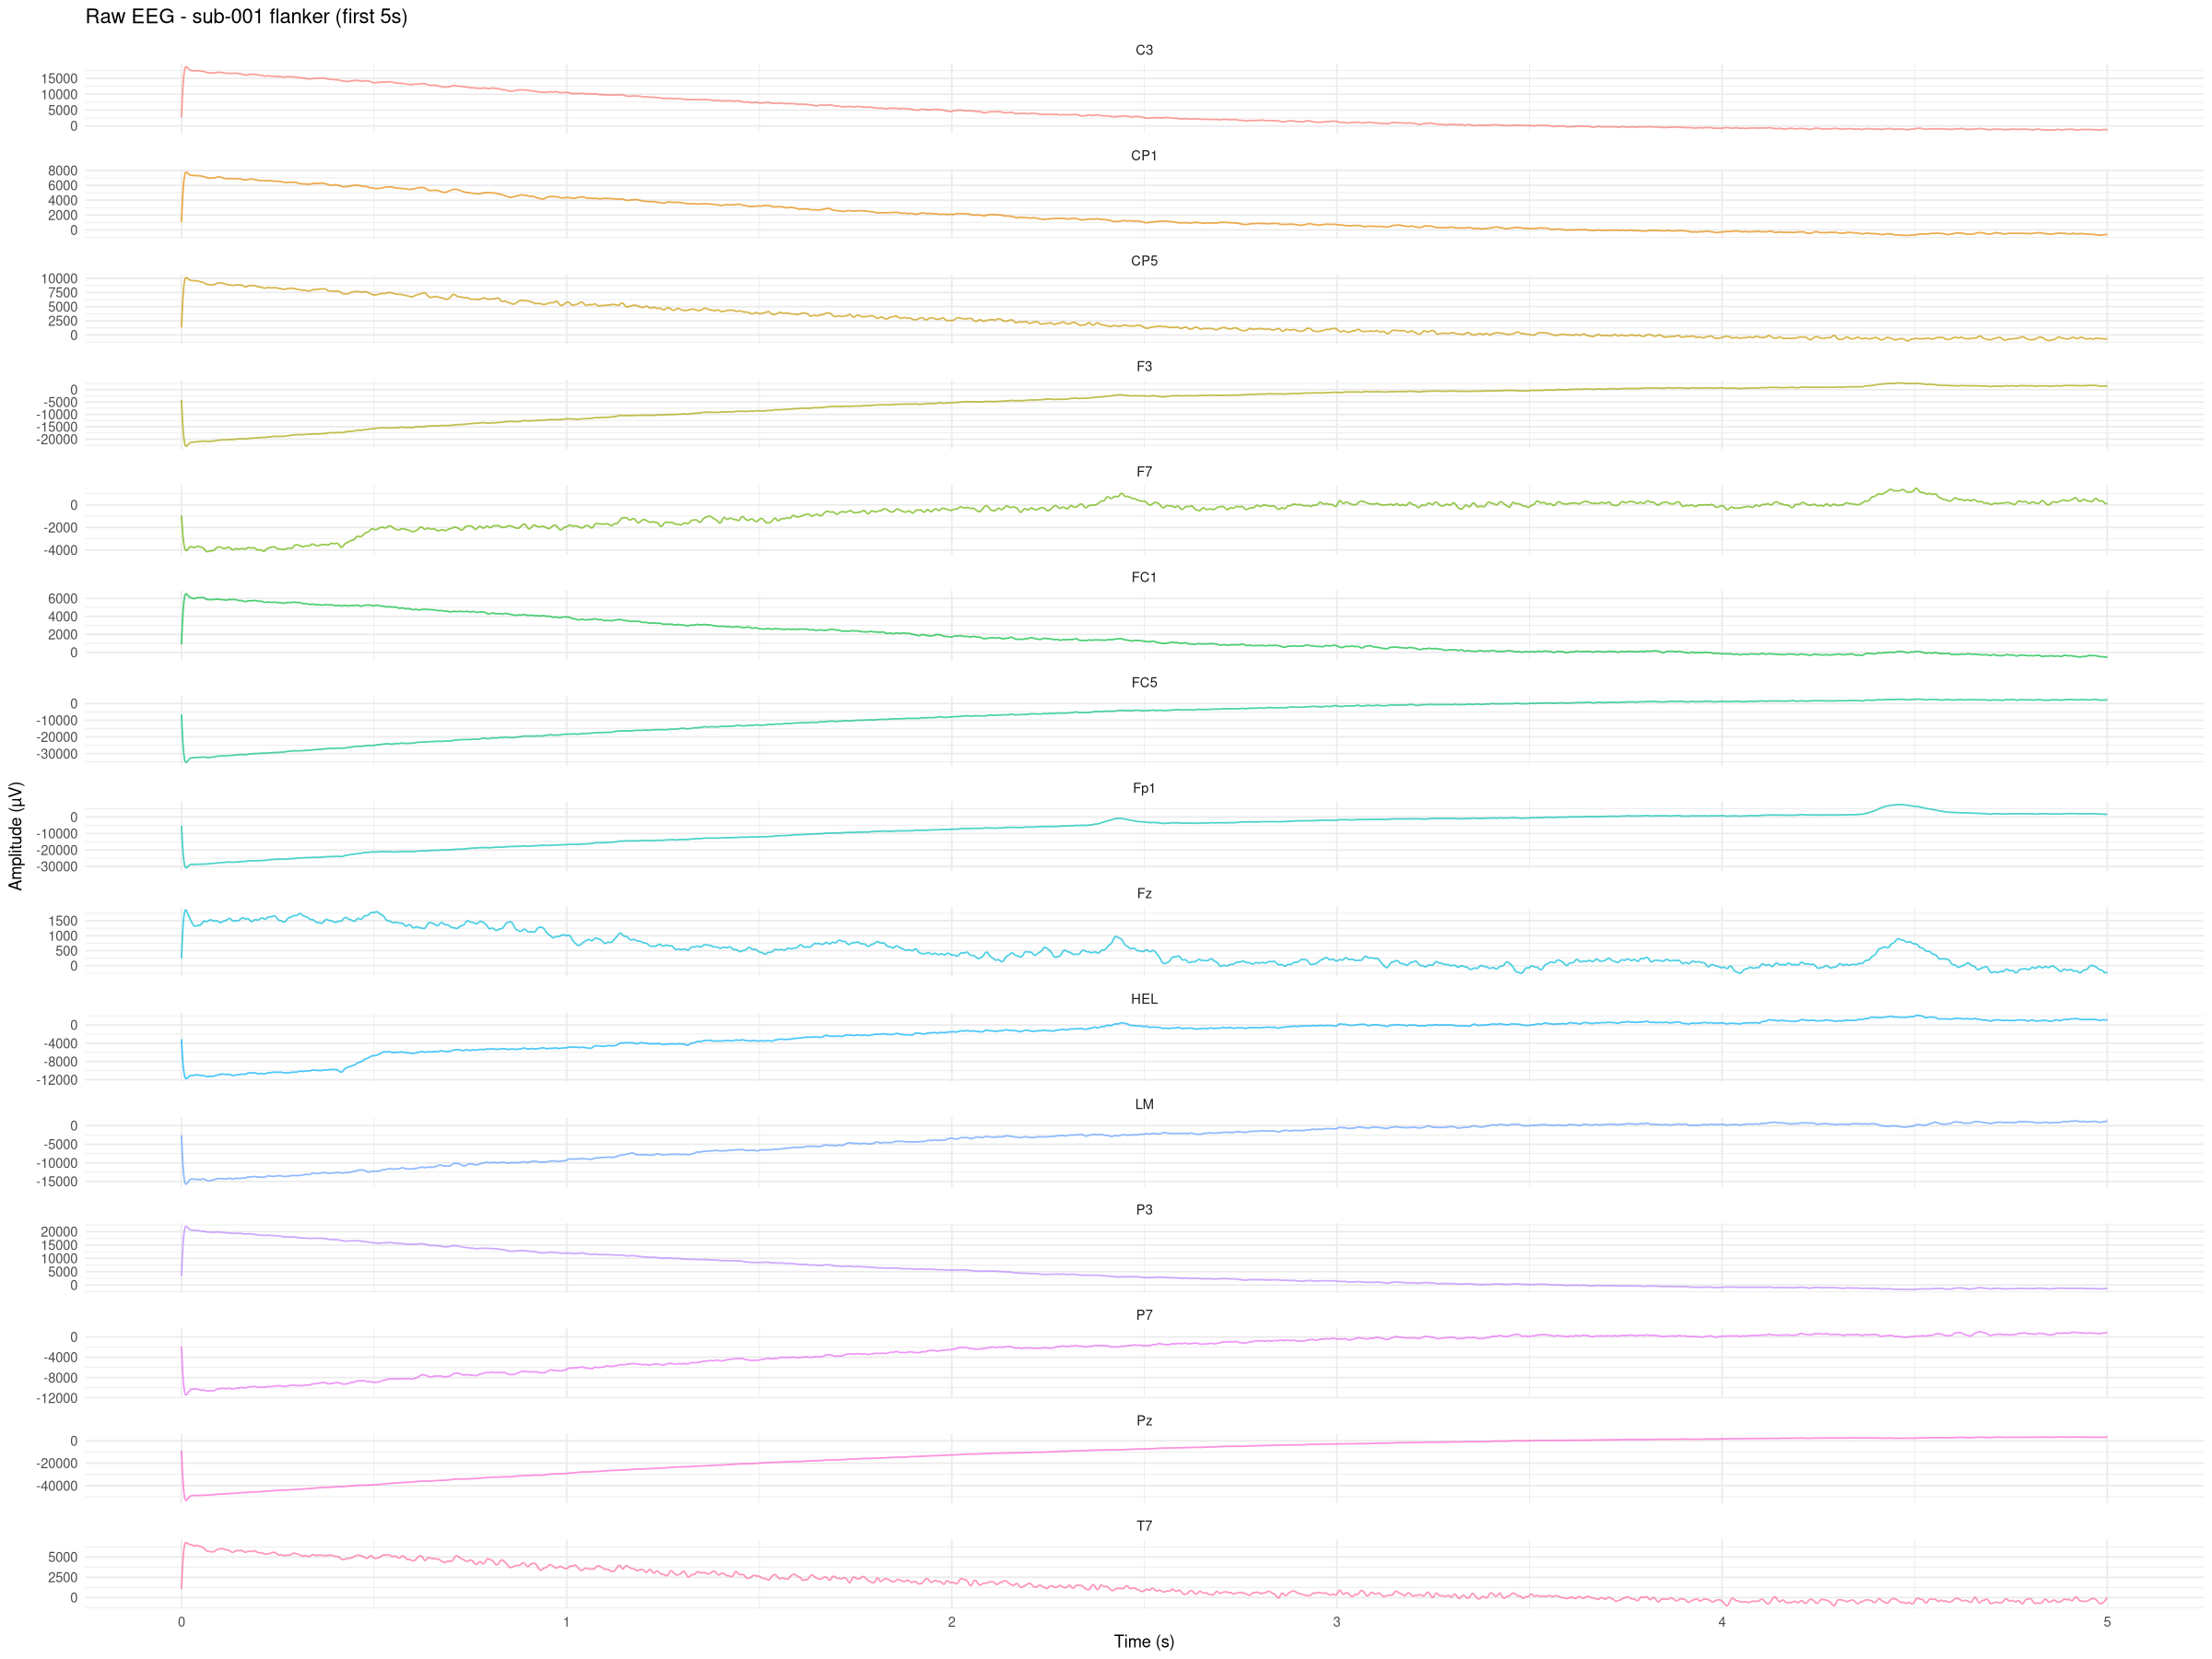

In [10]:
# 3. Plot the data to inspect for noise
# TODO: find correct eegUtils plot function for raw eeg_data objects
# plot_timecourse() requires epoched data; plot_electrode() not available
# Workaround: convert to data frame and plot with ggplot2
library(ggplot2)
library(tidyr)
raw_df   <- as.data.frame(raw)
channels <- colnames(raw$signals)[1:15]
raw_sub  <- raw_df[raw_df$time <= 5, c("time", channels)]
raw_long <- pivot_longer(raw_sub, -time, names_to = "channel", values_to = "amplitude")
ggplot(raw_long, aes(x = time, y = amplitude, colour = channel)) +
  geom_line(alpha = 0.7) +
  facet_wrap(~channel, ncol = 1, scales = "free_y") +
  labs(title = "Raw EEG - sub-001 flanker (first 5s)",
       x = "Time (s)", y = "Amplitude (µV)") +
  theme_minimal() +
  theme(legend.position = "none")